# Algorithm for leaf growth

In [1]:
import math
import os
import matplotlib.pyplot as plt
import numpy as np
from datetime import date
from scipy.optimize import brentq
from scipy.interpolate import CubicSpline, splev, splrep

from plot_outputs import *

from openalea.archicrop.stics_io import read_sti_file, stics_output
from openalea.archicrop.cereal_axis import bell_shaped_dist, geometric_dist
from openalea.archicrop.cereal_leaf import sr_dornbush
from openalea.archicrop.growth import demand_dist, demand_dist_bis, equal_dist, dev_dist
from openalea.archicrop.viability import resolve_organ_growth, compute_skew

from ipywidgets import interact, interactive, IntSlider, FloatSlider, fixed, Play, HBox, VBox, jslink

In [12]:
from openalea.archicrop.stics_io import get_stics_data

tec_file='../data/usms_STICS/v10/02NT18SorgV2D1_tec.xml'
plant_file='../data/usms_STICS/v10/plant/sorgho_imp_M_v10_plt.xml'
stics_output_file='../data/usms_STICS/v10/mod_s02NT18SorgV2D1.sti'
stics_output_file_pot='../data/usms_STICS/v10/mod_s02NT18SorgV2D1_no_stress.sti'

density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)
density_pot, daily_dynamics_pot, lifespan_pot, lifespan_early_pot, thermal_time_pot, leaf_area_plant_pot, sen_leaf_area_plant_pot, height_canopy_pot, end_juv_pot, end_veg_pot, index_end_veg_pot = stics_output(tec_file, plant_file, stics_output_file_pot)

Inputs:
- number of phytomers $N_{phy}$
- development parameters: phyllochron $\phi$, ligulochron $lig$
- leaf area distribution in plant: $leaf\_area = f(rank, params)$ with $params = (r_{max}, skew)$
- maximal plant leaf area $S_{max}$

Steps:
- Define number of phytomers

In [13]:
nb_phy = 8
phyllochron = compute_phi(nb_phy, end_veg_pot)
ligul_factor = 1.6
ligulochron = ligul_factor * phyllochron

- Define leaf development from appearance to ligulation 

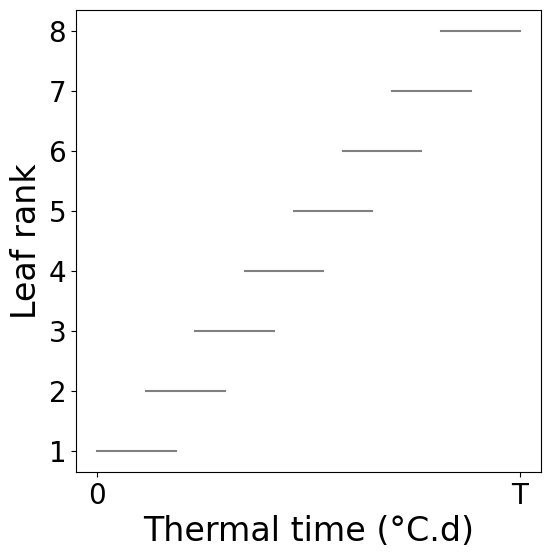

In [14]:
def dev(phyllochron, ligulochron, nb_phy):

    fig = plt.figure(figsize=(6, 6))
    for i in range(1,nb_phy+1):
        start = (i-1) * phyllochron
        end = start + ligulochron
        plt.plot(np.linspace(start, end, 2), [i,i], color="gray")

    plt.yticks(range(1,nb_phy+1), fontsize=20)
    plt.xticks([0,end_veg_pot], labels=[0,'T'], fontsize=20)
    plt.xlabel("Thermal time (°C.d)", fontsize=24)
    plt.ylabel("Leaf rank", fontsize=24)
    today_str = date.today().strftime("%Y-%m-%d")
    os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
    plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/dev.png", dpi=1000)
    plt.show()

dev(phyllochron, ligulochron, nb_phy)
# interact(dev, phyllochron=IntSlider(min=20,max=100,step=5,value=45), ligulochron=IntSlider(min=50,max=160,step=5,value=80), nb_phy=fixed(nb_phy))

- Define allometric law for relative leaf area as a function of phytomer rank

In [ ]:
def bell(rmax, skew, nb_phy=100):

    leaf_areas = bell_shaped_dist(1, nb_phy, rmax, skew)
    fig = plt.figure(figsize=(3.5, 5.5))
    plt.plot(leaf_areas, range(1,len(leaf_areas)+1), color="gray")
    plt.xticks([])  # Remove x-axis ticks
    plt.yticks([])  # Remove y-axis ticks
    plt.xlabel("Leaf surface", fontsize=18, fontname="Times New Roman")
    plt.ylabel("Leaf rank", fontsize=18, fontname="Times New Roman")
    today_str = date.today().strftime("%Y-%m-%d")
    os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
    plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/bell_shape.png", dpi=1000)
    plt.show()

interact(bell, rmax=FloatSlider(min=0.1,max=1.0,step=0.05,value=0.7), skew=FloatSlider(min=0.0001,max=1.0,step=0.0005,value=0.001))

interactive(children=(FloatSlider(value=0.7, description='rmax', max=1.0, min=0.1, step=0.05), FloatSlider(val…

<function __main__.bell(rmax, skew, nb_phy=100)>

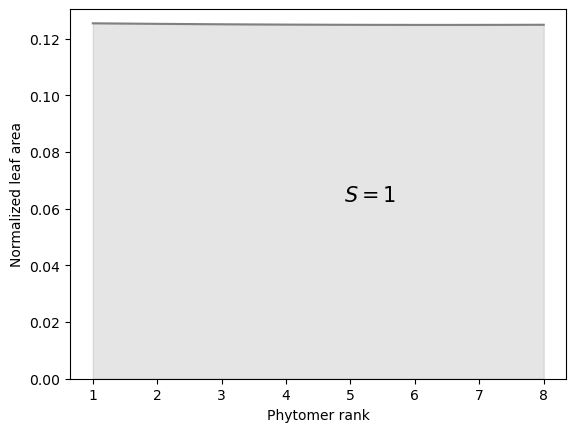

In [16]:
rmax = 0.8
skew = 0.01
Smax = 1

leaf_areas = bell_shaped_dist(Smax, nb_phy, rmax, skew)

plt.plot(range(1,len(leaf_areas)+1), leaf_areas, color="gray")
plt.fill_between(range(1,len(leaf_areas)+1), [0]*len(leaf_areas), leaf_areas, color="gray", alpha=0.2)
plt.ylim(0,max(leaf_areas)+0.005)
plt.xlabel("Phytomer rank")
plt.ylabel("Normalized leaf area")
plt.text(rmax*nb_phy-1.5, max(leaf_areas)/2, '$S = 1$', fontsize = 15)
plt.show()

- Scale the leaf areas according to the given maximal plant leaf area $S_{max}$

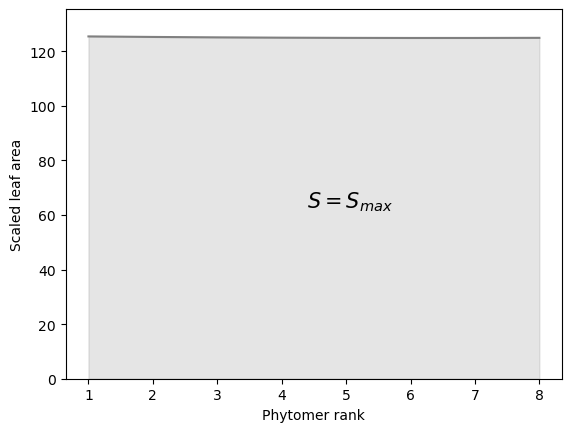

In [17]:
Smax = 1000
scaled_leaf_areas = bell_shaped_dist(Smax, nb_phy, rmax, skew)

plt.plot(range(1,len(scaled_leaf_areas)+1), scaled_leaf_areas, color="gray")
plt.fill_between(range(1,len(scaled_leaf_areas)+1), [0]*len(scaled_leaf_areas), scaled_leaf_areas, color="gray", alpha=0.2)
plt.ylim(0,max(scaled_leaf_areas)+10)
plt.xlabel("Phytomer rank")
plt.ylabel("Scaled leaf area")
plt.text(rmax*nb_phy-2, max(scaled_leaf_areas)/2, '$S = S_{max}$', fontsize = 15)
plt.show()

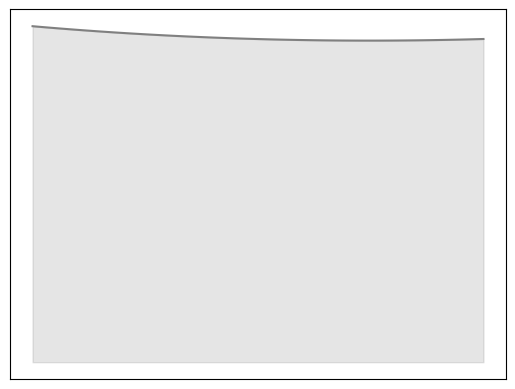

In [18]:
scaled_leaf_areas = bell_shaped_dist(leaf_area=1, nb_phy=100, rmax=0.75, skew=0.08)

plt.plot(range(1,len(scaled_leaf_areas)+1), scaled_leaf_areas, color="gray")
plt.fill_between(range(1,len(scaled_leaf_areas)+1), [0]*len(scaled_leaf_areas), scaled_leaf_areas, color="gray", alpha=0.2)
plt.xticks([])
plt.yticks([])
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/bell_shape_fig_1.png", dpi=1000)
plt.show()

[3, 6, 9, 12, 15.70827204415217, 32.20195769051193, 49.520327619189715, 67.70461604430139, 86.79811889066865, 106.84629687935426, 127.89688376747412, 150.0]


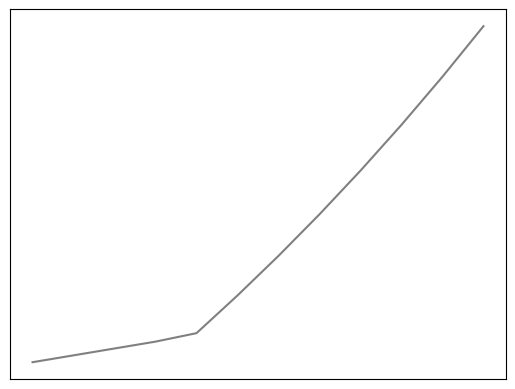

In [19]:
ligule_heights = [3*i for i in range(1,5)] + geometric_dist(height=150, nb_phy=8, q=1.05, u0=3*5) 
print(ligule_heights)

plt.plot(range(1,len(ligule_heights)+1), ligule_heights, color="gray")
plt.xticks([])
plt.yticks([])
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/ligule_heights_fig_1.png", dpi=1000)
plt.show()

- At each time step, knowing H0, add the leaf area increment of each growing organ to the sum of appeared leaf area. 

In [20]:
def linear_leaf_growth(phyllochron, ligulochron, nb_phy):

    fig, ax1 = plt.subplots()

    starts = []
    ends = []

    for i in range(nb_phy):
        start = i * phyllochron
        end = start + ligulochron
        
        starts.append(start)
        ends.append(end)
        ax1.plot(np.linspace(start, end, 2), [0,scaled_leaf_areas[i]], color="gray")
        ax1.text(end-4, scaled_leaf_areas[i]+3, f'{i+1}', fontsize = 10)

    S = []
    
    for t in np.arange(max(ends)):
        sum_temp = 0
        for i,(s,e) in enumerate(zip(starts,ends)):
            if s <= t < e:
                sum_temp += (t-s)/(e-s) * scaled_leaf_areas[i]
            elif t >= e:
                sum_temp += scaled_leaf_areas[i]
        S.append(sum_temp)                
    
   
    ax1.set_xlabel("t", fontsize=24)
    ax1.set_ylabel("Leaf area", fontsize=24)
    ax1.set_yticks([])
    ax1.set_xticks([0,max(ends)], labels=[0,'T'], fontsize=20)
    # ax1.fill_between([end/1.95,end/1.95+25], 0, max(scaled_leaf_areas), color="grey", alpha=0.4)
             
    ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
    
    ax2.set_ylabel("Plant leaf area", fontsize=24)
    ax2.fill_between(range(len(S)), [0]*len(S), S, color="gray", alpha=0.2)
    ax2.set_yticks([0,max(S)], labels=[0,r'$S_{max}$'], fontsize=20)
    
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()

linear_leaf_growth(phyllochron, ligulochron, nb_phy)
# interact(linear_leaf_growth, phyllochron=IntSlider(min=30,max=60,step=5,value=45), ligulochron=IntSlider(min=50,max=100,step=5,value=80), nb_phy=fixed(nb_phy))

C:\Users\cheriere\AppData\Local\Temp\ipykernel_13556\3972130848.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()  # otherwise the right y-label is slightly clipped


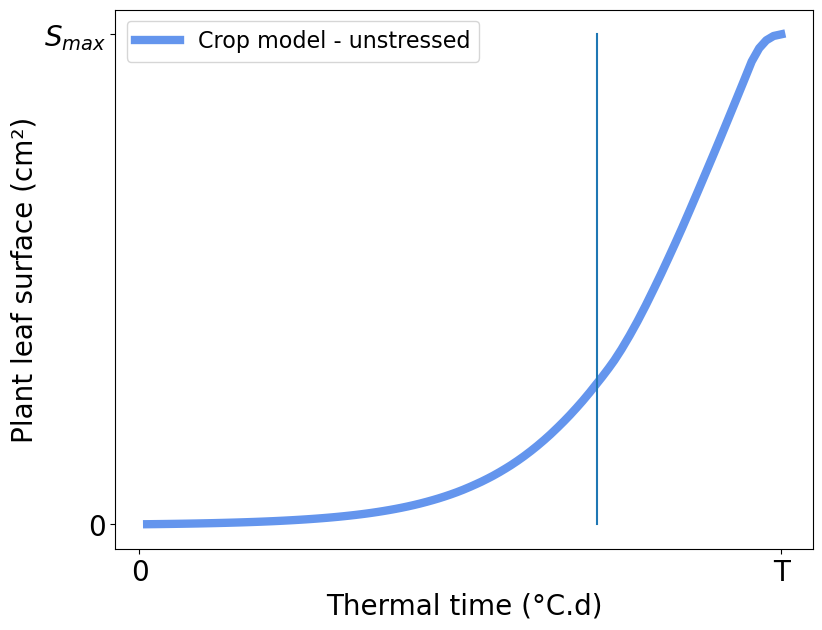

In [21]:
fig = plt.figure(figsize=(9, 7))
plt.plot(thermal_time[:index_end_veg+1], leaf_area_plant_pot[:index_end_veg+1], color="cornflowerblue", linewidth=6, label='Crop model - unstressed')
plt.plot([end_juv]*2,[0,leaf_area_plant_pot[index_end_veg+1]])
plt.xlabel("Thermal time (°C.d)", fontsize=20)
plt.ylabel("Plant leaf surface (cm²)", fontsize=20)
plt.xticks([0,end_veg_pot], labels=[0,'T'], fontsize=20)
plt.legend(fontsize=16)
plt.yticks([0,max(leaf_area_plant_pot)], labels=[0,r'$S_{max}$'])
plt.tick_params(labelsize=20)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/LAI_unstressed.png", dpi=1000)
plt.show()

In [22]:
# n_samples = 6

# param_sets = param_sampling(archi_params=archi, n_samples=n_samples)

# daily_dynamics = {i:{"Thermal time": t, "Phenology": 'juvenile' if t < 300 else 'exponential' if t < 900 else 'repro'} 
#                   for i,t in enumerate(range(0,1000,20))}

# pot_la, pot_h, mtgs = compute_pot_growth(param_sets, daily_dynamics)

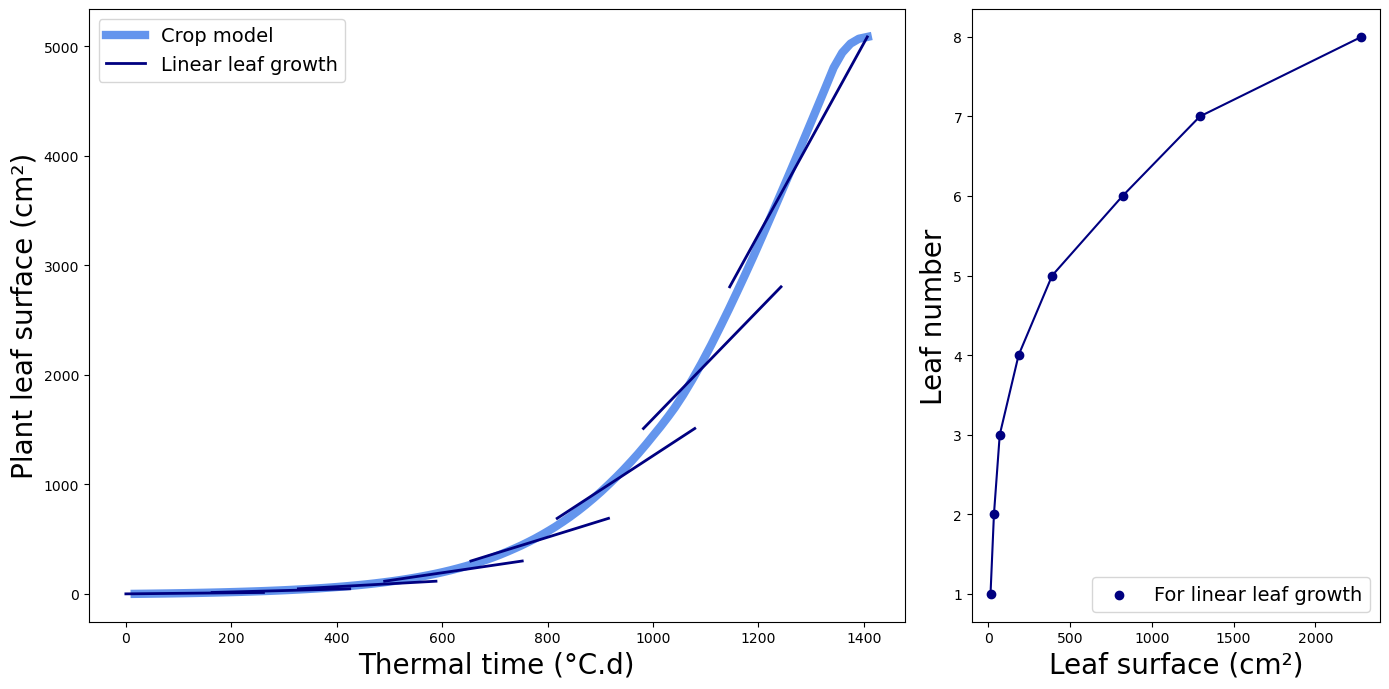

In [23]:
def linear_leaf_growth_on_constraint(nb_phy, ligul_factor, thermal_time, leaf_area_plant, end_veg, index_end_veg, pot_factor, growth=True):

    phyllochron = end_veg / (nb_phy - 1 + ligul_factor)
    ligulochron = int(phyllochron * ligul_factor)

    leaf_area_plant = leaf_area_plant[:index_end_veg+1]
    thermal_time = thermal_time[:index_end_veg+1]
    spl = splrep(thermal_time, leaf_area_plant)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), width_ratios=[2,1])
    ax1.plot(thermal_time, leaf_area_plant, linewidth=6, color="cornflowerblue", label="Crop model")

 
    starts = []
    ends = []

    for i in range(nb_phy):
        start = i * phyllochron
        end = start + ligulochron
        
        starts.append(start)
        ends.append(end)
  
    la_starts = splev(starts, spl)
    la_ends = splev(ends, spl)

    leaf_areas,_,_,_ = resolve_organ_growth(nb_phy, ligul_factor, la_ends)
            

    if growth:
        for i,la in enumerate(leaf_areas):
            if i == 0:
                ax1.plot(np.linspace(starts[i], ends[i], 2), [0, leaf_areas[i]], color="navy", linewidth=2, label="Linear leaf growth")
            else:
                ax1.plot(np.linspace(starts[i], ends[i], 2), [sum(leaf_areas[:i]), sum(leaf_areas[:i+1])], linewidth=2, color="navy")

    else:
        for i,la in enumerate(leaf_areas):
            if i == 0:
                ax1.plot(np.linspace(starts[i], ends[i], 2), [leaf_areas[i]/2, leaf_areas[i]/2], color="navy", linewidth=2, label="Leaf development")
            else:
                ax1.plot(np.linspace(starts[i], ends[i], 2), [(sum(leaf_areas[:i]) + sum(leaf_areas[:i+1]))/2, (sum(leaf_areas[:i]) + sum(leaf_areas[:i+1]))/2], linewidth=2, color="navy")


    range_tt = range(round(thermal_time[0]), round(thermal_time[-1]))
    interp_la = splev(range_tt, spl)
    rates_la = [interp_la[i]-interp_la[i-1] if i > 0 else 0 for i in range(len(interp_la))]

    S = []
    for t in np.arange(max(ends)):
        sum_temp = 0
        for i,(s,e) in enumerate(zip(starts,ends)):
            if s <= t < e:
                sum_temp += (t-s)/(e-s) * leaf_areas[i]
            elif t >= e:
                sum_temp += leaf_areas[i]
        S.append(sum_temp)
    
    ax1.set_xlabel("Thermal time (°C.d)", fontsize=20)
    ax1.set_ylabel("Plant leaf surface (cm²)", fontsize=20)
    ax1.legend(fontsize=14)

    for i, la in enumerate(leaf_areas):
        if la == max(leaf_areas):
            id_max = i+1
            break

    rmax_int = np.arange(max(0,(id_max-1)/nb_phy), min(1,(id_max+1)/nb_phy), 0.02)
   
    leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
    
    skews_rmax = []
    for rank in range(1, nb_phy+1):
        for rmax in rmax_int:
            if rmax != rank/nb_phy and leaf_areas[rank-1] > 0:
                skew = compute_skew(rank=rank, nb_phy=nb_phy, rmax=rmax, leaf_areas=leaf_areas_norm)
                if 1e-10 < skew < 1.0:
                    skews_rmax.append((skew, rmax))

    skew_int = []
    rejected_skews = []
    label_green_set = False
    label_grey_set = False
    for skew,rmax in skews_rmax:
        bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant[-1]*pot_factor, nb_phy, rmax, skew)
        for i,bs in enumerate(bell_shaped_leaf_areas):
            if bs < leaf_areas[i]: #-(0.05*max(leaf_areas)):
                color = "grey"
                break
            else:
                color = "black"
        if color == "black" and not label_green_set:
            ax2.plot(bell_shaped_leaf_areas, range(1,nb_phy+1), color=color, alpha=0) #, label="Viable")
            label_green_set = True
        elif color == "black":
            ax2.plot(bell_shaped_leaf_areas, range(1,nb_phy+1), color=color, alpha=0)
        elif color == "grey" and not label_grey_set:
            ax2.plot(bell_shaped_leaf_areas, range(1,nb_phy+1), alpha=0, color=color) #, label="Non-viable")
            label_grey_set = True
        else:
            ax2.plot(bell_shaped_leaf_areas, range(1,nb_phy+1), alpha=0, color=color)
        if color == "black":
            skew_int.append(skew)
        else:
            rejected_skews.append(skew)
    
    ax2.plot(leaf_areas, range(1,nb_phy+1), color="navy", linestyle="-")
    ax2.scatter(leaf_areas, range(1,nb_phy+1), color="navy", label="For linear leaf growth")
    ax2.set_ylabel("Leaf number", fontsize=20)
    ax2.set_xlabel("Leaf surface (cm²)", fontsize=20)
    ax2.legend(fontsize=14, loc="lower right")

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    today_str = date.today().strftime("%Y-%m-%d")
    os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
    if growth:
        plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/pot_leaf_growth_phyllochron{phyllochron}_ligulochron{ligul_factor}_pot_factor_{pot_factor}.png", dpi=1000)
    else:
        plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/pot_leaf_development_phyllochron{phyllochron}_ligulochron{ligul_factor}_pot_factor_{pot_factor}.png", dpi=1000)
    plt.show()

pot_factor = 1.5
linear_leaf_growth_on_constraint(nb_phy, ligul_factor, thermal_time_pot, leaf_area_plant_pot, end_veg_pot, index_end_veg_pot, pot_factor, growth=True)
# interact(linear_leaf_growth_on_constraint, 
#          nb_phy = IntSlider(min=8,max=40,step=1,value=16), 
#          ligul_factor = FloatSlider(min=1.0,max=3.0,step=0.1,value=1.6),
#          thermal_time = fixed(thermal_time), 
#          leaf_area_plant = fixed(leaf_area_plant), 
#          end_veg = fixed(thermal_time[index_end_veg]), 
#          index_end_veg = fixed(index_end_veg),
#          growth = fixed(True),
#          pot_factor = FloatSlider(min=1.0,max=2.0,step=0.05,value=1.4))

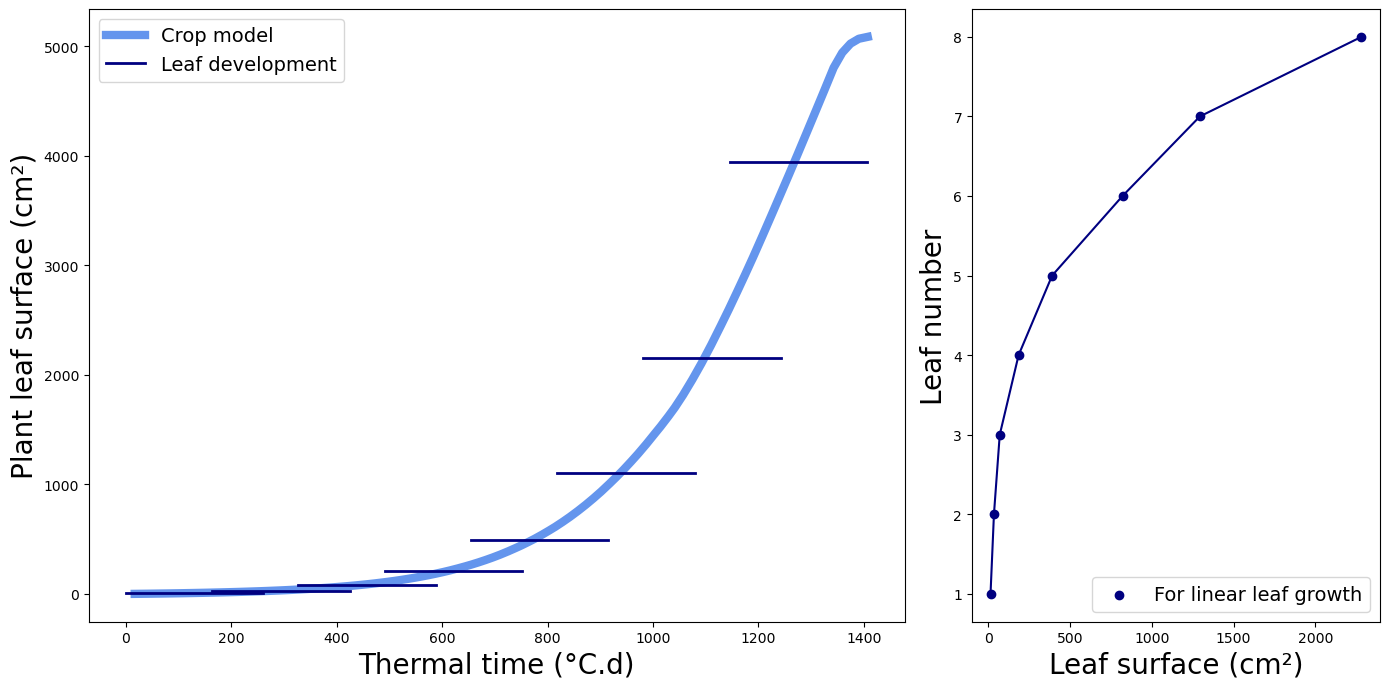

In [24]:
linear_leaf_growth_on_constraint(nb_phy, ligul_factor, thermal_time_pot, leaf_area_plant_pot, end_veg_pot, index_end_veg_pot, pot_factor, growth=False)

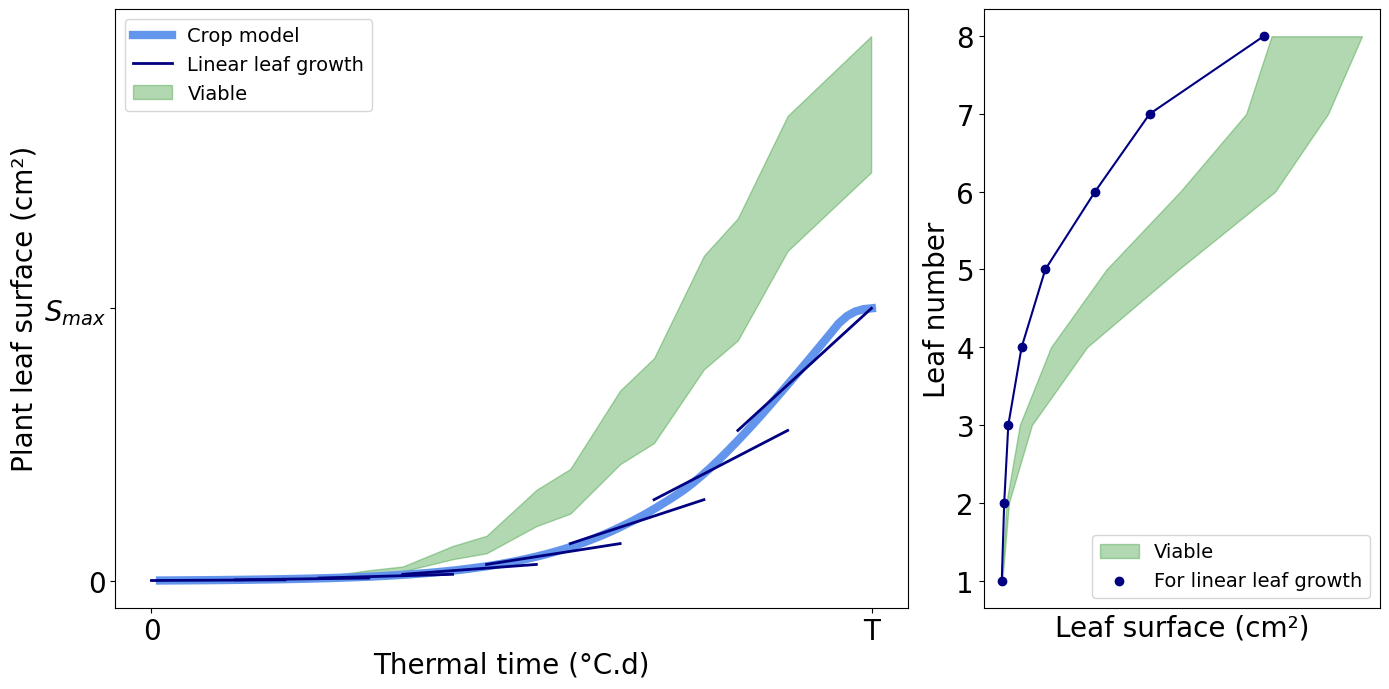

In [27]:
def linear_leaf_growth_viable(nb_phy, ligul_factor, thermal_time, leaf_area_plant, end_veg, index_end_veg):

    phyllochron = end_veg / (nb_phy - 1 + ligul_factor)
    ligulochron = int(phyllochron * ligul_factor)

    leaf_area_plant = leaf_area_plant[:index_end_veg+1]
    thermal_time = thermal_time[:index_end_veg+1]
    spl = splrep(thermal_time, leaf_area_plant)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), width_ratios=[2,1])
    ax1.plot(thermal_time, leaf_area_plant, linewidth=6, color="cornflowerblue", label="Crop model")

    starts = []
    ends = []

    for i in range(nb_phy):
        start = i * phyllochron
        end = start + ligulochron
        
        starts.append(start)
        ends.append(end)
  
    la_starts = splev(starts, spl)
    la_ends = splev(ends, spl)

    leaf_areas,_,_,_ = resolve_organ_growth(nb_phy, ligul_factor, la_ends)
            
    for i,la in enumerate(leaf_areas):
        if i == 0:
            ax1.plot(np.linspace(starts[i], ends[i], 2), [0, leaf_areas[i]], color="navy", linewidth=2, label="Linear leaf growth")
        else:
            ax1.plot(np.linspace(starts[i], ends[i], 2), [sum(leaf_areas[:i]), sum(leaf_areas[:i+1])], linewidth=2, color="navy")


    ax1.set_xlabel("Thermal time (°C.d)", fontsize=20)
    ax1.set_ylabel("Plant leaf surface (cm²)", fontsize=20)
   
    for i, la in enumerate(leaf_areas):
        if la == max(leaf_areas):
            id_max = i+1
            break

    rmax_int = np.arange(max(0,(id_max-1)/nb_phy), min(1,(id_max+1)/nb_phy), 0.02)

    leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
    
    skews_rmax = []
    for rank in range(1, nb_phy+1):
        for rmax in rmax_int:
            if rmax != rank/nb_phy and leaf_areas[rank-1] > 0:
                skew = compute_skew(rank=rank, nb_phy=nb_phy, rmax=rmax, leaf_areas=leaf_areas_norm)
                if -10 < skew < 0:
                    skews_rmax.append((skew, rmax))

    tt = np.arange(max(ends))
    mins_1 = np.zeros(len(tt))
    maxs_1 = np.zeros(len(tt))
    mins_2 = np.zeros(nb_phy)
    maxs_2 = np.zeros(nb_phy)

    for pot_factor in [1.0,1.1,1.2,1.3,1.4,1.5,2]:
        
        shapes = []
        for skew, rmax in skews_rmax:
            bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant_pot[-1] * pot_factor, nb_phy, rmax, skew)
            viable = True
            for i,bs in enumerate(bell_shaped_leaf_areas):
                if bs < leaf_areas[i]: 
                    viable = False
                    break
            if viable:
                shapes.append(bell_shaped_leaf_areas)
        
        for j,shape in enumerate(shapes):
            S = []
            for k,t in enumerate(tt):
                sum_temp = 0
                for i,(s,e) in enumerate(zip(starts,ends)):
                    if s <= t < e:
                        sum_temp += (t-s)/(e-s) * shape[i]
                    elif t >= e:
                        sum_temp += shape[i]
                if sum_temp < mins_1[k] or mins_1[k] == 0:
                    mins_1[k] = sum_temp
                if sum_temp > maxs_1[k]:
                    maxs_1[k] = sum_temp
                S.append(sum_temp)

        if len(shapes) > 0:
            shapes = np.array(shapes)
            mins_2 = np.array([new if new < old or old == 0 else old for old, new in zip(mins_2, shapes.min(axis=0))])
            maxs_2 = np.array([new if new > old or old == 0 else old for old, new in zip(maxs_2, shapes.max(axis=0))])

    ax1.fill_between(tt, 
                     mins_1, # [m*density/100**2 for m in mins], 
                     maxs_1, # [m*density/100**2 for m in maxs], 
                     alpha = 0.3, color='green', label="Viable")

    skew_int = []
    rejected_skews = []
    label_green_set = False
    label_grey_set = False
    for skew,rmax in skews_rmax:
        bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant[-1]*pot_factor, nb_phy, rmax, skew)
        for i,bs in enumerate(bell_shaped_leaf_areas):
            if bs < leaf_areas[i]: #-(0.05*max(leaf_areas)):
                color = "grey"
                break
            else:
                color = "green"
                
                S = []
                for t in np.arange(max(ends)):
                    sum_temp = 0
                    for i,(s,e) in enumerate(zip(starts,ends)):
                        if s <= t < e:
                            sum_temp += (t-s)/(e-s) * bell_shaped_leaf_areas[i]
                        elif t >= e:
                            sum_temp += bell_shaped_leaf_areas[i]
                    S.append(sum_temp)
                    
        if color == "green" and not label_green_set:
            # ax2.plot(bell_shaped_leaf_areas, range(1,nb_phy+1), color=color, label="Viable")
            # ax1.plot(range(int(thermal_time[0]),len(S)), S[int(thermal_time[0]):], color=color, alpha=0.7, label="Viable")
            label_green_set = True
        # elif color == "green":
            # ax2.plot(bell_shaped_leaf_areas, range(1,nb_phy+1), color=color)
            # ax1.plot(range(int(thermal_time[0]),len(S)), S[int(thermal_time[0]):], color=color, alpha=0.7)
        elif color == "grey" and not label_grey_set:
            # ax2.plot(bell_shaped_leaf_areas, range(1,nb_phy+1), alpha=0.1, color=color, label="Non-viable")
            label_grey_set = True
        # else:
        #     ax2.plot(bell_shaped_leaf_areas, range(1,nb_phy+1), alpha=0.1, color=color)
        if color == "green":
            skew_int.append(skew)
        else:
            rejected_skews.append(skew)

    ax2.fill_betweenx(range(1,len(mins_2)+1), mins_2, maxs_2, color="green", alpha=0.3, label="Viable")

    ax2.plot(leaf_areas, range(1,nb_phy+1), color="navy", linestyle="-")
    ax2.scatter(leaf_areas, range(1,nb_phy+1), color="navy", label="For linear leaf growth")
    ax2.set_ylabel("Leaf number", fontsize=20)
    ax2.set_xlabel("Leaf surface (cm²)", fontsize=20)
    ax1.legend(fontsize=14)
    ax2.legend(fontsize=14)

    ax1.set_xticks([0,end_veg_pot], labels=[0,'T'], fontsize=20)
    ax1.set_yticks([0,max(leaf_area_plant_pot)], labels=[0,r'$S_{max}$'], fontsize=20)

    ax2.set_xticks([])
    ax2.set_yticks(range(1,nb_phy+1))

    plt.tick_params(labelsize=20)

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    today_str = date.today().strftime("%Y-%m-%d")
    os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
    plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/pot_leaf_growth_viable_phyllochron{phyllochron}_ligulochron{ligul_factor}.png", dpi=1000)
    plt.show()

linear_leaf_growth_viable(nb_phy, ligul_factor, thermal_time_pot, leaf_area_plant_pot, end_veg_pot, index_end_veg_pot)
# interact(linear_leaf_growth_viable, 
#          nb_phy = IntSlider(min=8,max=40,step=1,value=16), 
#          ligul_factor = fixed(1.6),
#          thermal_time = fixed(thermal_time), 
#          leaf_area_plant = fixed(leaf_area_plant), 
#          end_veg = fixed(thermal_time[index_end_veg]), 
#          index_end_veg = fixed(index_end_veg),
#          pot_factor = FloatSlider(min=1.0,max=2.0,step=0.05,value=1.4))

NameError: name 'tt' is not defined

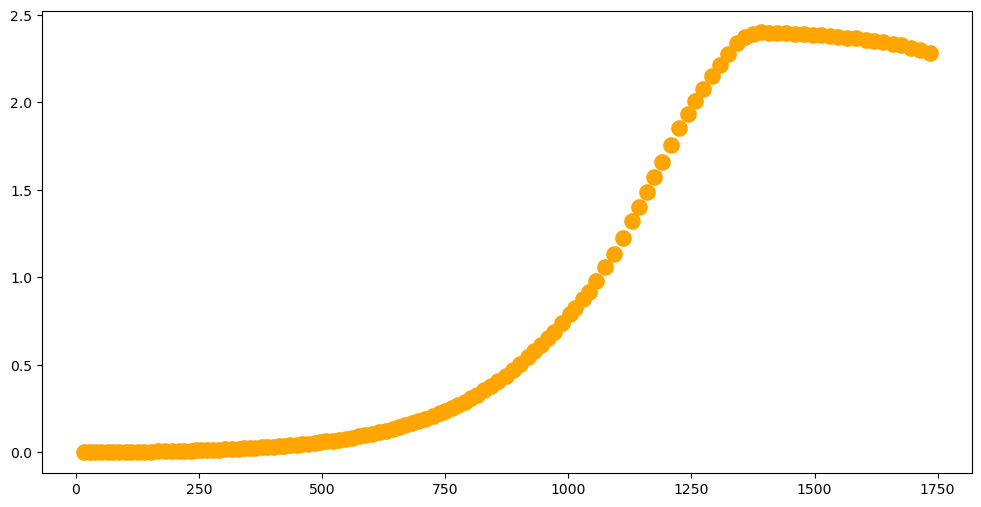

In [28]:
from openalea.archicrop.cereal_axis import bell_shaped_dist
from openalea.archicrop.viability import resolve_organ_growth, compute_skew
import math
import matplotlib.pyplot as plt

leaf_area_plant_pot_grow = leaf_area_plant_pot[:index_end_veg_pot+2]
thermal_time_pot_grow = thermal_time_pot[:index_end_veg_pot+2]
spl = splrep(thermal_time_pot, leaf_area_plant_pot)

fig, ax1 = plt.subplots(figsize=(12, 6))
plt.scatter(thermal_time, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="orange", linewidth=6, label='STICS stressed')
# plt.plot(thermal_time, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="coral", linewidth=3, label='ArchiCrop stressed')

first = True
mins = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))
maxs = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))

n = nb_phy

end_veg_pot = thermal_time_pot[index_end_veg_pot+1]

phi = {n : compute_phi(n, end_veg_pot)}
rmax = {n : compute_rmax(n, end_veg_pot, index_end_veg_pot, thermal_time_pot, leaf_area_plant_pot)}

d = {n: [(phi[n], r) for r in rmax[n]]}

for _,l in d.items():
    for p,r in l:
        ligulochron = p * 1.6
        starts = []
        ends = []
        for i in range(n):
            start = i * p
            end = start + ligulochron
            starts.append(start)
            ends.append(end)
        
        la_starts = splev(starts, spl)
        la_ends = splev(ends, spl)
        
        leaf_areas,_,_,_ = resolve_organ_growth(n, 1.6, la_ends)
        leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
    
        skews = []
        for rank in range(1, n+1):
            if r != rank/n and leaf_areas[rank-1] > 0:
                skew = compute_skew(rank=rank, nb_phy=n, rmax=r, leaf_areas=leaf_areas_norm)
                if 1e-10 < skew < 1.0:
                    skews.append(skew)
    
        for pot_factor in [1.0,1.25,1.5,1.75]:
            
            shapes = []
            for skew in skews:
                bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant_pot[-1] * pot_factor, n, r, skew)
                viable = True
                for i,bs in enumerate(bell_shaped_leaf_areas):
                    if bs < leaf_areas[i]: 
                        viable = False
                        break
                if viable:
                    shapes.append(bell_shaped_leaf_areas)
            
            for j,shape in enumerate(shapes):
                S = []
                tt = np.arange(max(ends))
                # print(len(tt))
                for k,t in enumerate(tt):
                    sum_temp = 0
                    for i,(s,e) in enumerate(zip(starts,ends)):
                        if s <= t < e:
                            sum_temp += (t-s)/(e-s) * shape[i]
                        elif t >= e:
                            sum_temp += shape[i]
                    if sum_temp < mins[k] or mins[k] == 0:
                        mins[k] = sum_temp
                    if sum_temp > maxs[k]:
                        maxs[k] = sum_temp
                    S.append(sum_temp)
            
                # if first:
                #     ax1.plot(tt, S, color='cornflowerblue', linestyle='dotted', alpha=0.2, label="Viable")
                #     first = False
                # else:
                #     ax1.plot(tt, S, color='cornflowerblue', linestyle='dotted', alpha=0.2)

ax1.fill_between(np.concatenate((tt,np.array(thermal_time_pot[index_end_veg_pot+2:]))), 
                 [m*density/100**2 for m in mins]+[max(mins)*density/100**2]*len(thermal_time_pot[index_end_veg_pot+2:]), 
                 [m*density/100**2 for m in maxs]+[max(maxs)*density/100**2]*len(thermal_time_pot[index_end_veg_pot+2:]), 
                 alpha = 0.3, color='green', label="Viable")
ax1.set_xlabel("t", fontsize=24)
ax1.set_ylabel("LAI", fontsize=24)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.legend(fontsize=15)
# ax1.tick_params(labelsize=20)


today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/result_2_viable_morphospace_dynamics.png", dpi=1000)
plt.show()

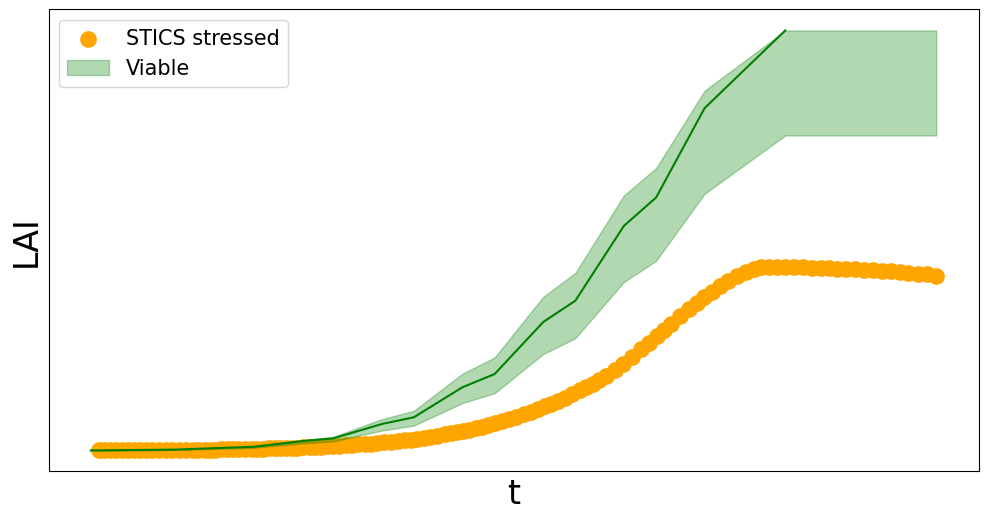

In [31]:
leaf_area_plant_pot_grow = leaf_area_plant_pot[:index_end_veg_pot+2]
thermal_time_pot_grow = thermal_time_pot[:index_end_veg_pot+2]
spl = splrep(thermal_time_pot, leaf_area_plant_pot)

fig, ax1 = plt.subplots(figsize=(12, 6))
plt.scatter(thermal_time, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="orange", linewidth=6, label='STICS stressed')
# plt.plot(thermal_time, [(la-sen)*density/10000 for la,sen in zip(leaf_area_plant, sen_leaf_area_plant)], color="coral", linewidth=3, label='ArchiCrop stressed')

first = True
mins = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))
maxs = np.zeros(len(np.arange(0,thermal_time_pot[index_end_veg_pot+1])))

n = nb_phy

end_veg_pot = thermal_time_pot[index_end_veg_pot+1]

phi = {n : compute_phi(n, end_veg_pot)}
rmax = {n : compute_rmax(n, end_veg_pot, index_end_veg_pot, thermal_time_pot, leaf_area_plant_pot)}

d = {n: [(phi[n], r) for r in rmax[n]]}

for _,l in d.items():
    for p,r in l:
        ligulochron = p * 1.6
        starts = []
        ends = []
        for i in range(n):
            start = i * p
            end = start + ligulochron
            starts.append(start)
            ends.append(end)
        
        la_starts = splev(starts, spl)
        la_ends = splev(ends, spl)
        
        leaf_areas,_,_,_ = resolve_organ_growth(n, 1.6, la_ends)
        leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
    
        skews = []
        for rank in range(1, n+1):
            if r != rank/n and leaf_areas[rank-1] > 0:
                skew = compute_skew(rank=rank, nb_phy=n, rmax=r, leaf_areas=leaf_areas_norm)
                if -10 < skew < 0:
                    skews.append(skew)
    
        for pot_factor in [1.0,1.25,1.5,1.75,2]:
            
            shapes = []
            for skew in skews:
                bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant_pot[-1] * pot_factor, n, r, skew)
                viable = True
                for i,bs in enumerate(bell_shaped_leaf_areas):
                    if bs < leaf_areas[i]: 
                        viable = False
                        break
                if viable:
                    shapes.append(bell_shaped_leaf_areas)
            
            for j,shape in enumerate(shapes):
                S = []
                tt = np.arange(max(ends))
                # print(len(tt))
                for k,t in enumerate(tt):
                    sum_temp = 0
                    for i,(s,e) in enumerate(zip(starts,ends)):
                        if s <= t < e:
                            sum_temp += (t-s)/(e-s) * shape[i]
                        elif t >= e:
                            sum_temp += shape[i]
                    if sum_temp < mins[k] or mins[k] == 0:
                        mins[k] = sum_temp
                    if sum_temp > maxs[k]:
                        maxs[k] = sum_temp
                    S.append(sum_temp)
            
ax1.plot(tt, [s*density/100**2 for s in S]+[max(S)]*(len(thermal_time_pot)-len(S)), color='green')

ax1.fill_between(np.concatenate((tt,np.array(thermal_time_pot[index_end_veg_pot+2:]))), 
                 [m*density/100**2 for m in mins]+[max(mins)*density/100**2]*len(thermal_time_pot[index_end_veg_pot+2:]), 
                 [m*density/100**2 for m in maxs]+[max(maxs)*density/100**2]*len(thermal_time_pot[index_end_veg_pot+2:]), 
                 alpha = 0.3, color='green', label="Viable")
ax1.set_xlabel("t", fontsize=24)
ax1.set_ylabel("LAI", fontsize=24)
ax1.set_xticks([])
ax1.set_yticks([])
ax1.legend(fontsize=15)
# ax1.tick_params(labelsize=20)


today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/result_2_viable_morphospace_dynamics_one_curve.png", dpi=1000)
plt.show()

At each time step, distribute the increment of given plant leaf area $\frac{dS_{constraint}(t)}{dt}$ among $g$ growing leaves.

Let’s consider $F(\alpha_1 x_1,…,\alpha_g x_g) = \sum_{i=1}^{g} \alpha_i x_i$, where $\sum_{i=1}^{g} \alpha_i = 1$ and $x_i = ds_i$ or $dh_i$

 


$H_{1.0}$ : Equal distribution of the gain among all growing vegetative organs 

For a growing leaf $i$ among $g$ growing leaves in a plant, given a plant leaf area increment $dS(t)$ for the plant at time $t$, the leaf area increment $ds_i(t)$ is:   
$ds_i(t)=\frac{dS(t)}{g}$ with $\alpha_1=\dots=\alpha_g=\frac{1}{g}$
 

In [13]:
def equal_distribution(ds, g):
    return [ds/g for i in range(g)]

$H_{1.1}$: Demand of leaf area proportionnal to final area

For a growing leaf $i$ of potential leaf area $S_{i}^{max}$ among $g$ growing leaves in a plant, given a plant leaf area increment $dS(t)$ for the plant at time $t$, the leaf area increment $ds_i(t)$ is:   
$ds_i(t)=\alpha_i \times  dS(t) $ such that $\alpha_{i} = \frac{S_{i}^{max}}{\sum^{g}_{j=1} S_{j}^{max}} $ and $\sum^{g}_{i=1} \alpha_{i} = 1$

In [14]:
def demand_related_distribution(ds, potential_areas_growing_leaves):
    sum_areas_growing_leaves = sum(potential_areas_growing_leaves)
    return [ds*pi/sum_areas_growing_leaves for pi in potential_areas_growing_leaves]

ds = 10
potential_areas_growing_leaves = [5,8,6]
print(demand_related_distribution(ds, potential_areas_growing_leaves))

[2.6315789473684212, 4.2105263157894735, 3.1578947368421053]


## From leaf area increment to leaf length increment

In [37]:
wl = 0.12

In [38]:
def leaf_elongation(l, dl):
    sp, rp = sr_dornbush()
    ss = int(l*100)
    dss = int(dl*100)
    rp = np.array([wl*r for r in rp])
    plt.figure(figsize=(12,1.4))
    plt.plot(sp, rp, color="g")
    plt.plot(sp, -rp, color="g")
    plt.plot(sp,[0]*len(rp), color="g", alpha=0.2)
    plt.fill_between(sp[-ss:], -rp[-ss:], rp[-ss:], color="g", alpha=1)
    plt.fill_between(sp[-(ss+dss):-ss+1], -rp[-(ss+dss):-ss+1], rp[-(ss+dss):-ss+1], color="orange", alpha=1)
    plt.gca().set_axis_off()
    today_str = date.today().strftime("%Y-%m-%d")
    os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  
    plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/leaf_growing_l{l}_dl{dl}.png", dpi=1000)
    plt.show()

interact(leaf_elongation, l=FloatSlider(min=0.01,max=1.001,step=0.01,value=0.02), dl=FloatSlider(min=0.0,max=1.0,step=0.05,value=0.3))

interactive(children=(FloatSlider(value=0.02, description='l', max=1.001, min=0.01, step=0.01), FloatSlider(va…

<function __main__.leaf_elongation(l, dl)>